In [165]:
import numpy as np
import matplotlib.pyplot as plt

In [166]:
# ===============================
# ======== PARAMETERS ===========
# ===============================

# This will be a bit more useful towards the later stage. 
# I will set most of the mmanually inside of functions 
# (I think it is prettier). But in case I change my mind

N=1
n=1000

i = np.linspace(N-1, N, n)
h = i[1] - i[0]

In [167]:
def solve_static_model(I, sigma=0.7, K=3.0, L=1.0, n=1000):

    # productivity = 0.2 for all tasks
    gamma = np.full(n, 0.2)
    eta = np.full(n, 0.2)   

    # CES
    power = (sigma - 1) / sigma

    # [0, I]
    capital_tasks = i <= I
    # (I, 1]
    labour_tasks = i > I

    # Solving integrals using Rieman sums
    A_K = np.sum(eta[capital_tasks] ** power) * h
    A_L = np.sum(gamma[labour_tasks] ** power) * h

    # output
    Y = (A_K ** (1 / sigma) * K ** power + A_L ** (1 / sigma) * L ** power) ** (1/power)

    # wage and rental rate
    W = (Y * A_L / L) ** (1/sigma)
    R = (Y * A_K / K) ** (1/sigma)

    s_L = (W * L) / Y

    return Y, W, R, s_L

In [ ]:
def solve_on_I_domain(I_domain, **kwargs):

    results = {
        'Y': np.zeros_like(I_domain),
        'W': np.zeros_like(I_domain),
        'R': np.zeros_like(I_domain),
        's_L': np.zeros_like(I_domain)
    }  

    for k, I in enumerate(I_domain):
        Y, W, R, s_L = solve_static_model(I, **kwargs)

        results['Y'][k] = Y
        results['W'][k] = W
        results['R'][k] = R
        results['s_L'][k] = s_L

    return results


In [169]:
sig_less_1 = 0.7
sig_more_1 = 1.5

data_sigma_less_than_1 = solve_on_I_domain(i, sigma = sig_less_1)
data_sigma_more_than_1 = solve_on_I_domain(i, sigma = sig_more_1)
data_simple = [data_sigma_less_than_1, data_sigma_more_than_1]

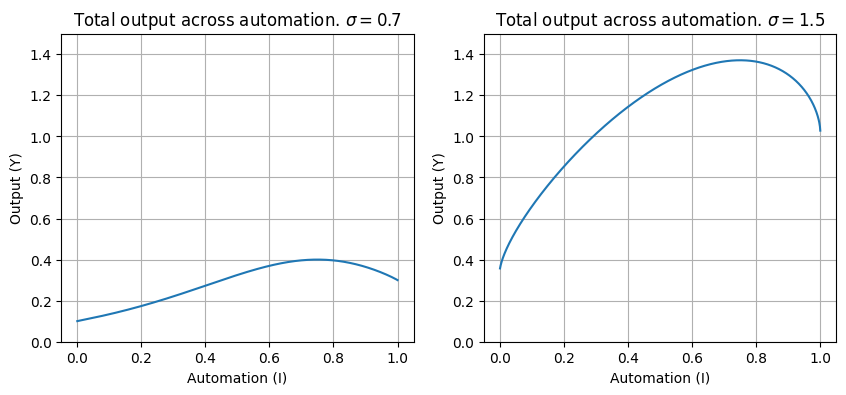

In [170]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for k, item in enumerate(data_simple):
    ax[k].plot(i, item['Y'])
    if item is data_sigma_less_than_1:
        ax[k].set_title(rf'Total output across automation. $\sigma = {sig_less_1}$')
    if item is data_sigma_more_than_1:
        ax[k].set_title(rf'Total output across automation. $\sigma = {sig_more_1}$')

    # Very important to not make misleading graphs and use the same y_lim when comparing two plots
    ax[k].set_ylim(0, 1.5) 

    ax[k].set_xlabel('Automation (I)')
    ax[k].set_ylabel('Output (Y)')
    ax[k].grid(True)
plt.show()

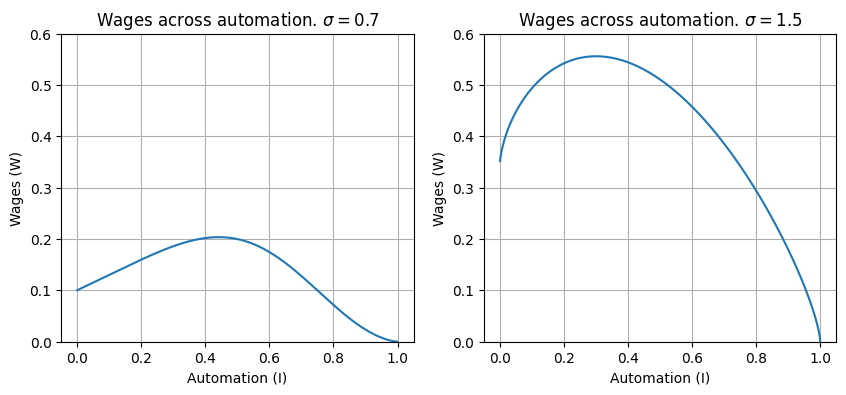

In [171]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for k, item in enumerate(data_simple):
    ax[k].plot(i, item['W'])
    if item is data_sigma_less_than_1:
        ax[k].set_title(rf'Wages across automation. $\sigma = {sig_less_1}$')
    if item is data_sigma_more_than_1:
        ax[k].set_title(rf'Wages across automation. $\sigma = {sig_more_1}$')
    
    ax[k].set_ylim(0, 0.6) 
    ax[k].set_xlabel('Automation (I)')
    ax[k].set_ylabel('Wages (W)')
    ax[k].grid(True)
plt.show()

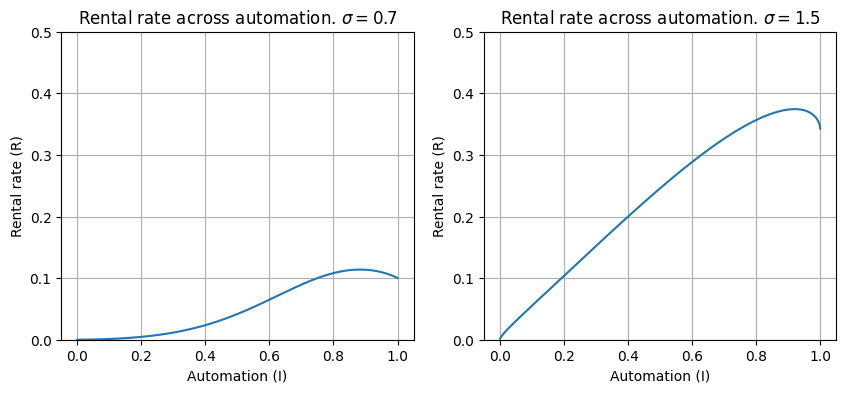

In [172]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for k, item in enumerate(data_simple):
    ax[k].plot(i, item['R'])
    if item is data_sigma_less_than_1:
        ax[k].set_title(rf'Rental rate across automation. $\sigma = {sig_less_1}$')
    if item is data_sigma_more_than_1:
        ax[k].set_title(rf'Rental rate across automation. $\sigma = {sig_more_1}$')

    ax[k].set_ylim(0, 0.5)
    ax[k].set_xlabel('Automation (I)')
    ax[k].set_ylabel('Rental rate (R)')
    ax[k].grid(True)
plt.show()

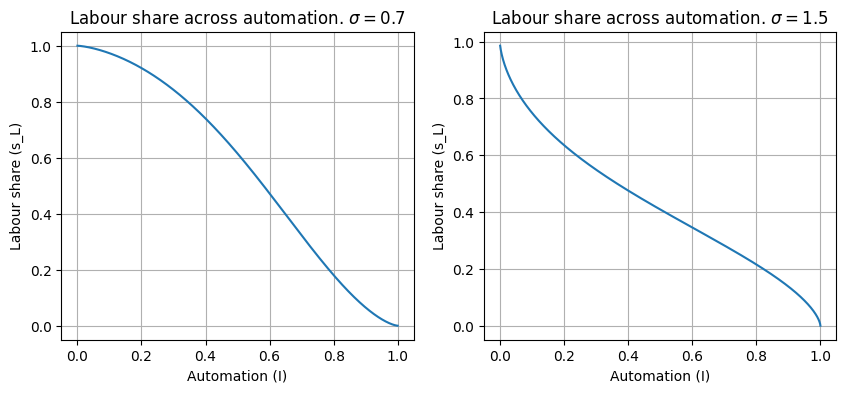

In [173]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for k, item in enumerate(data_simple):
    ax[k].plot(i, item['s_L'])
    if item is data_sigma_less_than_1:
        ax[k].set_title(rf'Labour share across automation. $\sigma = {sig_less_1}$')
    if item is data_sigma_more_than_1:
        ax[k].set_title(rf'Labour share across automation. $\sigma = {sig_more_1}$')

    # Not needed as labour share always є [0,1]
    # ax[k].set_ylim(0, 0.5)
    ax[k].set_xlabel('Automation (I)')
    ax[k].set_ylabel('Labour share (s_L)')
    ax[k].grid(True)
plt.show()